<a href="https://colab.research.google.com/github/AlexanderEgorovNRNUMEPHI/AIM-projects/blob/main/ML/Gradient%20boosting/HC_Egorov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import shap
import gc
from pathlib import Path
pd.options.display.max_rows = 100

import polars as pl
from glob import glob
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb


In [ ]:
#!pip install mlflow --quiet
#!pip install shap --quiet

## Загружать данные будем,  используя polars. При работе с pandas возникает нехватка памяти

In [ ]:
#!Плохо

#train = pd.read_parquet('H:/D/PycharmProjects/ML2/train_base_table.parquet')
#test = pd.read_parquet('H:/D/PycharmProjects/ML2/test_base_table.parquet')


## - Преобразуем колонки к нужным типам(используя инфо из соревнования)

## - даты будем переводить в дни и добавлять переменную разницы события с датой принятия решения, чтобы учесть временной сдвиг
  
## - почистим категории на предмет: выкинем колонки с одной категорией, с количеством нулов больше 80% и т.д.


In [ ]:
class DataManipulator:
    @staticmethod
    def set_table_dtypes(df):
        for col in df.columns:
            if col in ["case_id", "WEEK_NUM"]:
                df = df.with_columns(pl.col(col).cast(pl.Int32))
            elif col in ["date_decision"]:
                df = df.with_columns(pl.col(col).cast(pl.Date))
            elif col[-1] in ("P", "A"):
                df = df.with_columns(pl.col(col).cast(pl.Float64))
            elif col[-1] in ("M",):
                df = df.with_columns(pl.col(col).cast(pl.String))
            elif col[-1] in ("D",):
                df = df.with_columns(pl.col(col).cast(pl.Date))

        return df

    @staticmethod
    def handle_dates(df):
        for col in df.columns:
            if col[-1] in ("D",):
                df = df.with_columns(pl.col(col) - pl.col("date_decision"))
                df = df.with_columns(pl.col(col).dt.total_days())
                df = df.with_columns(pl.col(col).cast(pl.Float32))

        df = df.drop("date_decision", "MONTH")

        return df

    @staticmethod
    def filter_cols(df):
        for col in df.columns:
            if col not in ["target", "case_id", "WEEK_NUM"]:
                isnull = df[col].is_null().mean()

                if isnull > 0.8:
                    df = df.drop(col)

        for col in df.columns:
            if (col not in ["target", "case_id", "WEEK_NUM"]) & (df[col].dtype == pl.String):
                freq = df[col].n_unique()

                if (freq == 1) | (freq > 200):
                    df = df.drop(col)

            return df

## Будем проводить аггрегацию данных по аналогии с первым соревнованием. Для числовых переменных посчитаем какие-то статистики: среднее, максимум, минимум, стандартное отклонение.
## Для остальных типов колонок просто возьмем максимум

In [ ]:
class Aggregator:
    @staticmethod
    def num_expr(df):
        cols = [col for col in df.columns if col[-1] in ("P", "A")]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]
        expr_min = [pl.min(col).alias(f"min_{col}") for col in cols]
        expr_mean = [pl.mean(col).alias(f"mean_{col}") for col in cols]
        expr_std = [pl.std(col).alias(f"std_{col}") for col in cols]

        return expr_max + expr_min + expr_mean + expr_std

    @staticmethod
    def date_expr(df):
        cols = [col for col in df.columns if col[-1] in ("D",)]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max

    @staticmethod
    def str_expr(df):
        cols = [col for col in df.columns if col[-1] in ("M",)]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max


    @staticmethod
    def other_expr(df):
        cols = [col for col in df.columns if col[-1] in ("T", "L")]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max



    @staticmethod
    def get_exprs(df):
        exprs = Aggregator.num_expr(df) + \
                Aggregator.date_expr(df) + \
                Aggregator.str_expr(df) + \
                Aggregator.other_expr(df)
        return exprs

## Агрегацию будем проводить для всех данных кроме статической информации(так как ее считаем более ценной и будем рассматривать подробнее. Для этого будет использоваться разбиение по структуре данных, которую мы сами зададим ниже

In [ ]:
def read_files(regex_path, depth=None):
    chunks = []
    for path in glob(str(regex_path)):
        df = pl.read_parquet(path)
        df = df.pipe(DataManipulator.set_table_dtypes)

        if depth in [1, 2]:
            df = df.group_by("case_id").agg(Aggregator.get_exprs(df))

        chunks.append(df)

    df = pl.concat(chunks, how="vertical_relaxed")
    df = df.unique(subset=["case_id"])

    return df

def read_file(path, depth=None):
    df = pl.read_parquet(path)
    df = df.pipe(DataManipulator.set_table_dtypes)

    if depth in [1, 2]:
        df = df.group_by("case_id").agg(Aggregator.get_exprs(df))

    return df

## Дополнительно достанем из даты принятия решения год, месяц и день недели как отдельные фичи. Это может быть важно, так как в разные временные отрезки отдача кредита может отличаться(условно в год ковида скорее всего было больше реализаций дефолта)

## И соединим всю агрегированную информацию по case_id

In [ ]:
def get_features(base, depth_0, depth_1, depth_2):
    base = (
        base
        .with_columns(
            year_decision = pl.col("date_decision").dt.year(),
            month_decision = pl.col("date_decision").dt.month(),
            weekday_decision = pl.col("date_decision").dt.weekday(),
        )
    )

    for i, df in enumerate(depth_0 + depth_1 + depth_2):
        base = base.join(df, how="left", on="case_id", suffix=f"_{i}")

    base = base.pipe(DataManipulator.handle_dates)

    return base

In [ ]:
def to_pandas(df_data, cat_cols=None):
    df_data = df_data.to_pandas()

    if cat_cols is None:
        cat_cols = list(df_data.select_dtypes("object").columns)

    df_data[cat_cols] = df_data[cat_cols].astype("category")

    return df_data, cat_cols

In [ ]:
TRAIN_DIR = '/Users/r/PycharmProjects/ML/data/train/'

data_store = {
    "base": read_file("/Users/r/PycharmProjects/ML/data/train_base_table.parquet"),
    "depth_0": [
        read_file(TRAIN_DIR + "train_static_cb_0.parquet"),
        read_files(TRAIN_DIR + "train_static_0_*.parquet"),
    ],
    "depth_1": [
        read_files(TRAIN_DIR + "train_applprev_1_*.parquet", 1),
        read_file(TRAIN_DIR + "train_tax_registry_a_1.parquet", 1),
        read_file(TRAIN_DIR + "train_tax_registry_b_1.parquet", 1),
        read_file(TRAIN_DIR + "train_tax_registry_c_1.parquet", 1),
        read_files(TRAIN_DIR + "train_credit_bureau_a_1_*.parquet", 1),
        read_file(TRAIN_DIR + "train_credit_bureau_b_1.parquet", 1),
        read_file(TRAIN_DIR + "train_other_1.parquet", 1),
        read_file(TRAIN_DIR + "train_person_1.parquet", 1),
        read_file(TRAIN_DIR + "train_deposit_1.parquet", 1),
        read_file(TRAIN_DIR + "train_debitcard_1.parquet", 1),
    ],
    "depth_2": [
        read_file(TRAIN_DIR + "train_credit_bureau_b_2.parquet", 2),
        read_files(TRAIN_DIR + "train_credit_bureau_a_2_*.parquet", 2),
    ]
}

In [ ]:
df_train = get_features(**data_store).pipe(DataManipulator.filter_cols)
df_train, cat_cols = to_pandas(df_train)

del data_store
gc.collect()

0

## В качестве модели будем использовать градиентный бустинг lightgbm как отличный вариант для прототипирования.

## Строится несколько(5) моделей на стратифицированных фолдах(чтобы учесть время) и в качестве итогового скора используется усреднение по работе этих моделей.

## Параметр eta подбирался с помощью optuna по функциям из семинара(ниже) 1 раз и использовался во всех дальнейших расчетах


## Я попробовал варианты с is_unbalance True и False. Roc auc получается хуже в варианте с True. Это в том числе объяснялось на семинаре - сдвигаются скоры в сторону редкого класса и общая метрика ухудшается.


In [ ]:
X = df_train.drop(columns=["target", "case_id", "WEEK_NUM"])
y = df_train["target"]
weeks = df_train["WEEK_NUM"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=False)

models = []
for idx_train, idx_valid in cv.split(X, y, groups=weeks):
    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X.iloc[idx_valid], y.iloc[idx_valid]

    lgb_tr = lgb.Dataset(X_train, y_train, free_raw_data=False)

    params = {
        'objective': 'binary',
        'verbosity': 1,
        'num_threads': 32,
        'eta': 0.1,
        'is_unbalance': False,
    }
    lgb_val = lgb.Dataset(X_valid, y_valid, free_raw_data=False)
    params.update({'metric': 'auc'})
    model = lgb.train(params, lgb_tr, num_boost_round=130, valid_sets =[lgb_val], valid_names=['валидация'], callbacks=[lgb.log_evaluation(period=10)])
    models.append(model)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 31565, number of negative: 942582
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.406730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 78917
[LightGBM] [Info] Number of data points in the train set: 974147, number of used features: 435
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032403 -> initscore=-3.396574
[LightGBM] [Info] Start training from score -3.396574
[10]	валидация's auc: 0.793598
[20]	валидация's auc: 0.807656
[30]	валидация's auc: 0.816191
[40]	валидация's auc: 0.820907
[50]	валидация's auc: 0.824067
[60]	валидация's auc: 0.825963
[70]	валидация's auc: 0.827503
[80]	валидация's auc: 0.82853
[90]	валидация's auc: 0.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class FinalModel(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators):
        super().__init__()
        self.estimators = estimators

    def predict(self, X):
        y_preds = [estimator.predict(X) for estimator in self.estimators]
        return np.mean(y_preds, axis=0)


In [ ]:
model = FinalModel(models)


In [ ]:
model

FinalModel(estimators=[<lightgbm.basic.Booster object at 0x19427cc10>,
                       <lightgbm.basic.Booster object at 0x193813940>,
                       <lightgbm.basic.Booster object at 0x19427fc10>,
                       <lightgbm.basic.Booster object at 0x19427e3b0>,
                       <lightgbm.basic.Booster object at 0x19427f460>])

## Использование mlflow в своих исследованиях (до 5 баллов)

## Создаем эксперимент и логируем модель+ параметры
## infer_signature позволяет зафиксировать сигнатуру результата работы модели

In [ ]:
import mlflow
from mlflow.models import infer_signature

mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

experiment_id = mlflow.set_experiment('Credit risk AIM2024')
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.lightgbm.log_model(lgb_model=model, artifact_path='lightgbm-model')
    signature = infer_signature(X_train, y_train)


/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/_distutils_hack/__init__.py:11: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/_distutils_hack/__init__.py:26: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


## Можно сохранить модель, а потом загрузить ее и сделать предсказания

In [ ]:
logged_model = 'runs:/6844e3e928594b0eafb813200f4d6702/lightgbm-model'

# Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)

# Predict on a Pandas DataFrame.
train_predictions = loaded_model.predict(X_train)
print(train_predictions)
#signature = infer_signature(X_train, train_predictions)

[0.01652618 0.03123026 0.04558962 ... 0.07783805 0.07589993 0.01020836]


## Можно проводить селекцию запущенных моделей по какому-то правилу и выводить параметры выбранной модели

In [ ]:
client = mlflow.tracking.MlflowClient()
best_run = client.search_runs('1', max_results=1)[0]
best_run._data._params


{'objective': 'binary',
 'verbosity': '1',
 'num_threads': '32',
 'eta': '0.1',
 'is_unbalance': 'False',
 'metric': 'auc'}

## Если посмотреть plot_importance, то топ фичи являются категориальными. Работодатели и место(zipcode) действительно могут влиять на то, отдаст ли человек кредит. Но ниже мы дополнительно посмотрим shap и сравним результаты

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

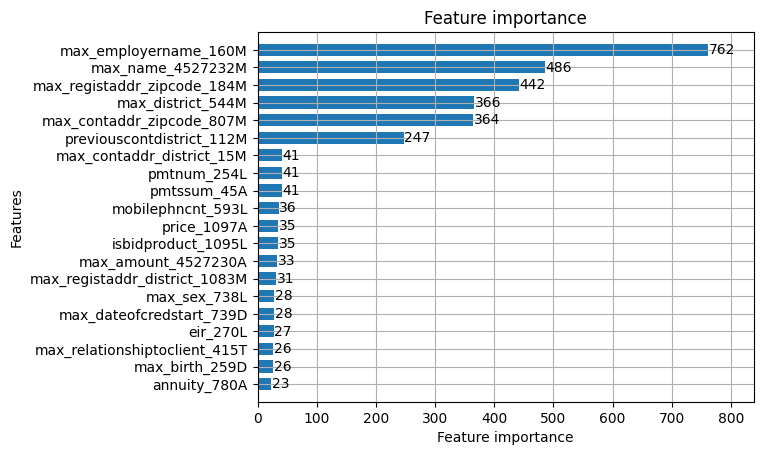

In [ ]:
lgb.plot_importance(model.estimators[0], height=0.7, ignore_zero=True, max_num_features=20)

## Ниже показано как подбирался параметр eta. Я не стал тюнить другие параметры, так как считаю что важнее поработать с данными

In [ ]:
%%time

from local_manipulations import *
param_info = {'eta': (1e-3, 0.5, 'float'), 'nthreads': 32}

study = start_lgb_random_search(param_info, X_train, y_train, X_valid, y_valid, n_trials=8)

/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/optuna/samplers/_tpe/sampler.py:319: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(


CPU times: user 23min 13s, sys: 16min 51s, total: 40min 5s
Wall time: 7min 27s


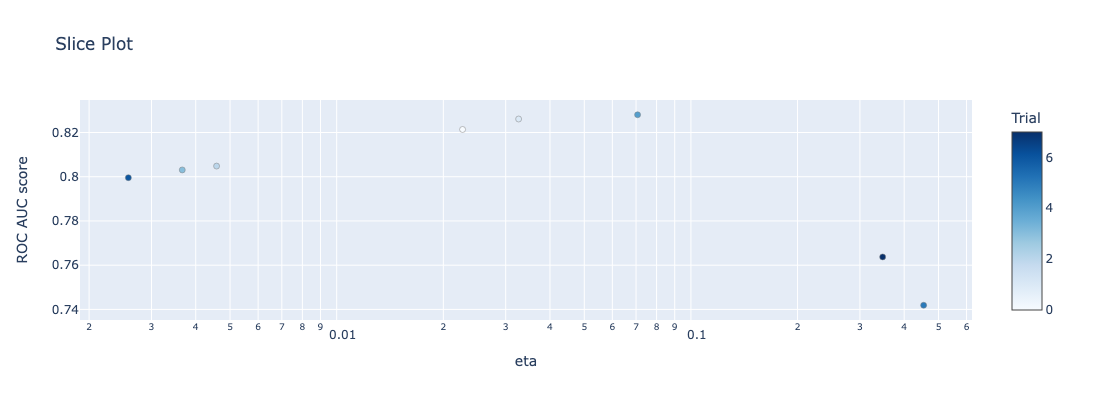

In [ ]:
from optuna.visualization import plot_slice

fig = plot_slice(study, target= lambda trial: trial.values[0], target_name= 'ROC AUC score')
fig.update_layout(height=400, width=600)

In [ ]:
TRAIN_DIR = '/Users/r/PycharmProjects/ML/data/train/'

data_store = {
    "base": read_file("/Users/r/PycharmProjects/ML/data/test_base_table.parquet"),
    "depth_0": [
        read_file(TRAIN_DIR + "train_static_cb_0.parquet"),
        read_files(TRAIN_DIR + "train_static_0_*.parquet"),
    ],
    "depth_1": [
        read_files(TRAIN_DIR + "train_applprev_1_*.parquet", 1),
        read_file(TRAIN_DIR + "train_tax_registry_a_1.parquet", 1),
        read_file(TRAIN_DIR + "train_tax_registry_b_1.parquet", 1),
        read_file(TRAIN_DIR + "train_tax_registry_c_1.parquet", 1),
        read_files(TRAIN_DIR + "train_credit_bureau_a_1_*.parquet", 1),
        read_file(TRAIN_DIR + "train_credit_bureau_b_1.parquet", 1),
        read_file(TRAIN_DIR + "train_other_1.parquet", 1),
        read_file(TRAIN_DIR + "train_person_1.parquet", 1),
        read_file(TRAIN_DIR + "train_deposit_1.parquet", 1),
        read_file(TRAIN_DIR + "train_debitcard_1.parquet", 1),
    ],
    "depth_2": [
        read_file(TRAIN_DIR + "train_credit_bureau_b_2.parquet", 2),
        read_files(TRAIN_DIR + "train_credit_bureau_a_2_*.parquet", 2),
    ]
}

In [ ]:
df_test = get_features(**data_store)
df_test = df_test.select([col for col in df_train.columns if col != 'target'])
df_test, cat_cols = to_pandas(df_test, cat_cols)

del data_store
gc.collect()

559

In [ ]:
X_test = df_test.drop(columns=["WEEK_NUM"])
X_test = X_test.set_index("case_id")
X_test['max_safeguarantyflag_411L']=X_test['max_safeguarantyflag_411L'].astype('bool')


In [ ]:
explainer = shap.TreeExplainer(model.estimators[0])
shap_values = explainer(X_test)

## Если посмотреть на shap, то часть фичей пропадает по сравнению с feature_importance, а часть имеет практически одни nanы. Возможно shap плохо работает с категориальными фичами.Ниже попробуем закодировать категориальные фичи через таргет и посмотрим, даст ли это большую прозрачность в интерпретации


In [ ]:
shap.initjs()

/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


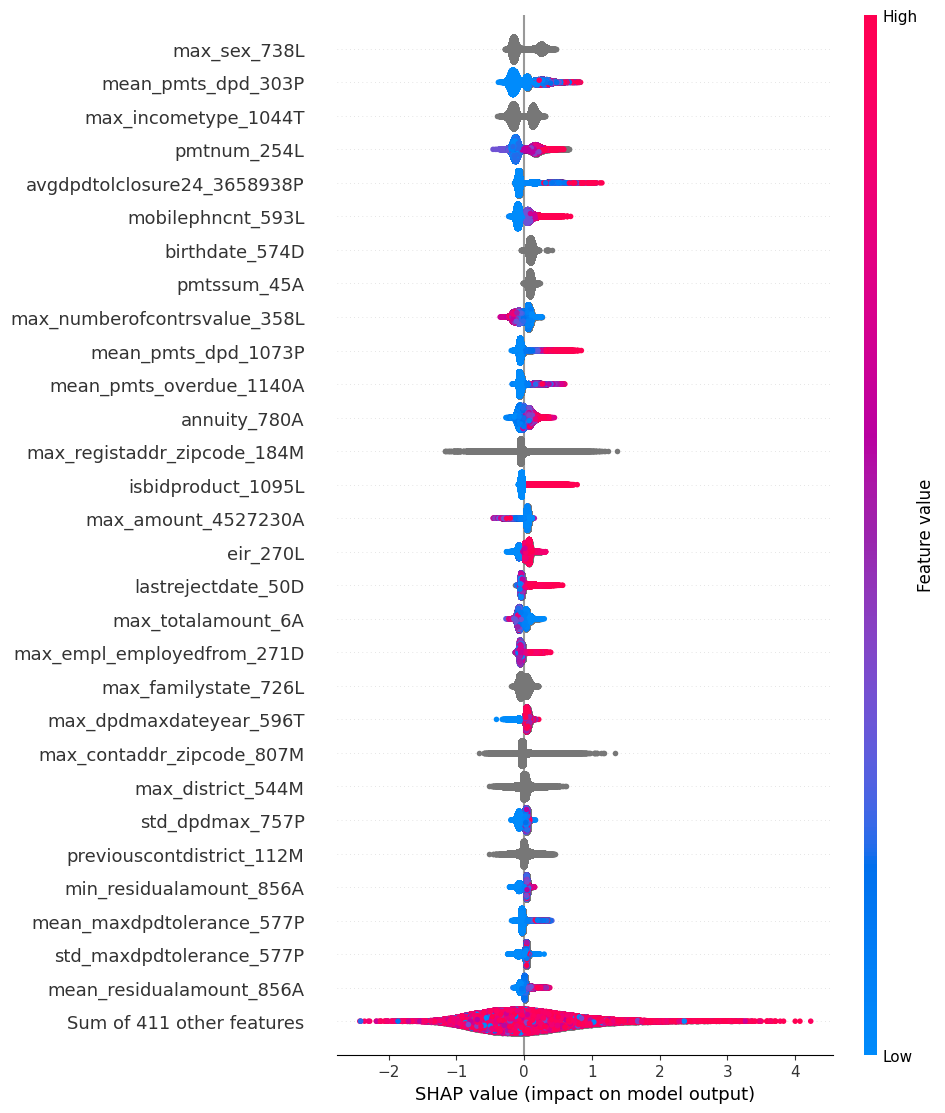

In [ ]:
shap.plots.beeswarm(shap_values, max_display=30)

In [ ]:
X_test.mean_pmts_dpd_1073P

case_id
46835        62.175000
47018         0.000000
47186         0.166667
47190         0.000000
47191      1125.208333
              ...     
2703450       0.000000
2703451       0.000000
2703452       0.444444
2703453       0.000000
2703454       0.000000
Name: mean_pmts_dpd_1073P, Length: 307510, dtype: float64

In [ ]:
y_pred = pd.Series(model.predict(X_test), index=X_test.index)
y_pred

case_id
46835      0.246666
47018      0.010146
47186      0.106959
47190      0.064125
47191      0.061075
             ...   
2703450    0.006841
2703451    0.013802
2703452    0.069775
2703453    0.004206
2703454    0.007893
Length: 307510, dtype: float64

## Перечисленные выше шаги давали на public скор в районе 0.84

In [ ]:
y_pred.name='score'
y_pred.to_csv('/Users/r/PycharmProjects/ML/data/train/submission.csv')

## Наблюдения при анализе данных и прочие находки (до 5 баллов).

## Попробуем закодировать категориальные признаки по таргету, как обсуждали на семинаре. Используется подход с экспоненциальным скользящим средним и зашумлением итоговых результатов для борьбы с переобучением

In [ ]:


def target_encode(train_series=None,
                  test_series=None,
                  target=None,
                  min_samples_leaf=1,
                  smoothing=1,
                  noise_level=0):
    """
    Smoothing is computed like in the following paper by Daniele Micci-Barreca
    https://kaggle2.blob.core.windows.net/forum-message-attachments/225952/7441/high%20cardinality%20categoricals.pdf
    train_series : training categorical feature as a pd.Series
    target : target data as a pd.Series
    min_samples_leaf (int) : minimum samples to take category average into account
    smoothing (int) : smoothing effect to balance categorical average vs prior
    """
    assert len(train_series) == len(target)
    assert train_series.name == test_series.name
    temp = pd.concat([train_series, target], axis=1)

    averages = temp.groupby(by=train_series.name)[target.name].agg(["mean", "count"])

    smoothing = 1 / (1 + np.exp(-(averages["count"] - min_samples_leaf) / smoothing))

    prior = target.mean()
    averages[target.name] = prior * (1 - smoothing) + averages["mean"] * smoothing
    averages.drop(["mean", "count"], axis=1, inplace=True)

    ft_train_series = pd.merge(
        train_series.to_frame(train_series.name),
        averages.reset_index().rename(columns={'index': target.name, target.name: 'average'}),
        on=train_series.name,
        how='left')['average'].rename(train_series.name + '_mean').fillna(prior)

    ft_train_series.index = train_series.index
    ft_test_series = pd.merge(
        test_series.to_frame(test_series.name),
        averages.reset_index().rename(columns={'index': target.name, target.name: 'average'}),
        on=test_series.name,
        how='left')['average'].rename(train_series.name + '_mean').fillna(prior)

    ft_test_series.index = test_series.index
    return add_noise(ft_train_series, noise_level), add_noise(ft_test_series, noise_level)

## Закодируем фичи и обучим модель заново

In [ ]:
category_columns = X.select_dtypes(include=["category"]).columns
X_coded = X.copy()
X_test_coded = X_test.copy()
y = df_train["target"]
for i in category_columns:
    X_coded[i], X_test_coded[i] = target_encode(X_coded[i],
                         X_test[i],
                         target=y,
                         min_samples_leaf=100,
                         smoothing=10,
                         noise_level=0.01)



/var/folders/cn/82z8dn7x17s921t8prxxpknskn0bx1/T/ipykernel_78118/76458701.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  averages = temp.groupby(by=train_series.name)[target.name].agg(["mean", "count"])
/var/folders/cn/82z8dn7x17s921t8prxxpknskn0bx1/T/ipykernel_78118/76458701.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  averages = temp.groupby(by=train_series.name)[target.name].agg(["mean", "count"])
/var/folders/cn/82z8dn7x17s921t8prxxpknskn0bx1/T/ipykernel_78118/76458701.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas.

In [ ]:
weeks = df_train["WEEK_NUM"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=False)

models2 = []
for idx_train, idx_valid in cv.split(X_coded, y, groups=weeks):
    X_train, y_train = X_coded.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X_coded.iloc[idx_valid], y.iloc[idx_valid]

    lgb_tr = lgb.Dataset(X_train, y_train, free_raw_data=False)

    params = {
        'objective': 'binary',
        'verbosity': 1,
        'num_threads': 32,
        'eta': 0.1,
        'is_unbalance': False,
    }
    lgb_val = lgb.Dataset(X_valid, y_valid, free_raw_data=False)
    params.update({'metric': 'auc'})
    model = lgb.train(params, lgb_tr, num_boost_round=100, valid_sets =[lgb_val], valid_names=['валидация'], callbacks=[lgb.log_evaluation(period=10)])
    models2.append(model)

[LightGBM] [Info] Number of positive: 31565, number of negative: 942582
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.664219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 83742
[LightGBM] [Info] Number of data points in the train set: 974147, number of used features: 437
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032403 -> initscore=-3.396574
[LightGBM] [Info] Start training from score -3.396574
[10]	валидация's auc: 0.793907
[20]	валидация's auc: 0.810202
[30]	валидация's auc: 0.820305
[40]	валидация's auc: 0.826524
[50]	валидация's auc: 0.831433
[60]	валидация's auc: 0.834232
[70]	валидация's auc: 0.836475
[80]	валидация's auc: 0.837912
[90]	валидация's auc: 0.839047
[100]	валидация's auc: 0.839869
[LightGBM] [Info] Number of positive: 31267, number of negative: 956647
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.672320 seconds.
You can set `fo

In [ ]:
model = FinalModel(models2)

In [ ]:
y_pred = pd.Series(model.predict(X_test_coded), index=X_test_coded.index)
y_pred

case_id
46835      0.236017
47018      0.009124
47186      0.120488
47190      0.061749
47191      0.059696
             ...   
2703450    0.003282
2703451    0.011349
2703452    0.089914
2703453    0.005323
2703454    0.006146
Length: 307510, dtype: float64

## Такой подход улучшает итоговый auc на примерно 0.06

In [ ]:
y_pred.name='score'
y_pred.to_csv('/Users/r/PycharmProjects/ML/data/train/submission.csv')

## Зато если теперь посмотреть на фичи через призму shap, то пропали почти все категориальные признаки, которые фигурировали в перовм рассмотрение через shap. Неуверен, но скорее всего там была просто неправильная обработка категориальных признаков

In [ ]:
explainer = shap.TreeExplainer(model.estimators[0])
shap_values = explainer(X_test_coded)

## Интерпретация итоговой модели (до 5 баллов)

## По такому shap уже кажется можно дать более осмысленные комментарии.
## Например:

## - last_reject_date: чем более недавно был отказ, тем выше вероятность дефолта
## - date_of_credit_start - выше вероятность дефолта у клиентов, которые недавно взяли кредит. Те кто платят долго и исправно скорее так и продолжат платить
## - mobilephncnt - как гипотеза, если у человека очень много мобильных номеров, то это может быть мошенник(фродовое поведение) и его вероятность дефолта ниже


/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


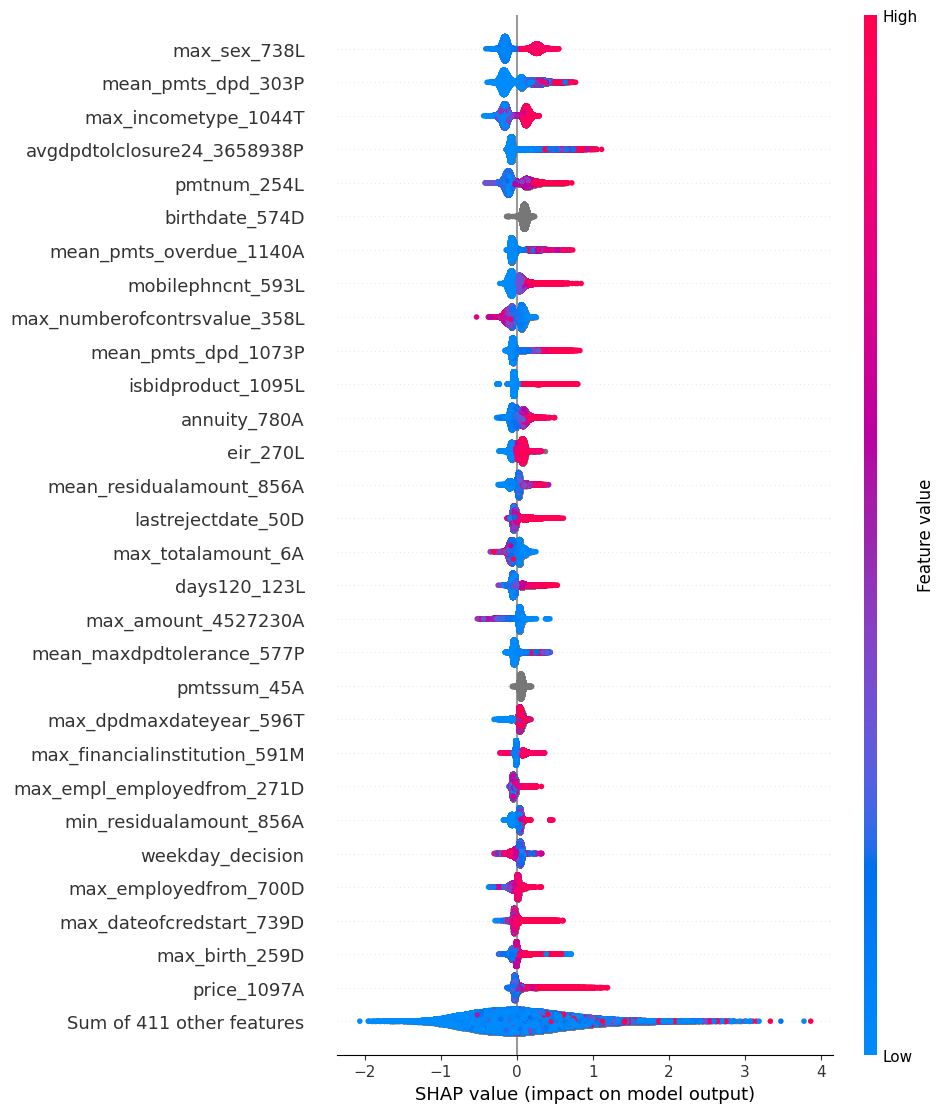

In [ ]:
shap.plots.beeswarm(shap_values, max_display=30)

# Я попробовал построить распредления по классам как в первом соревновании, но мало что из них извлек - большинство графиков выглядело как-то так и я их не привожу далее

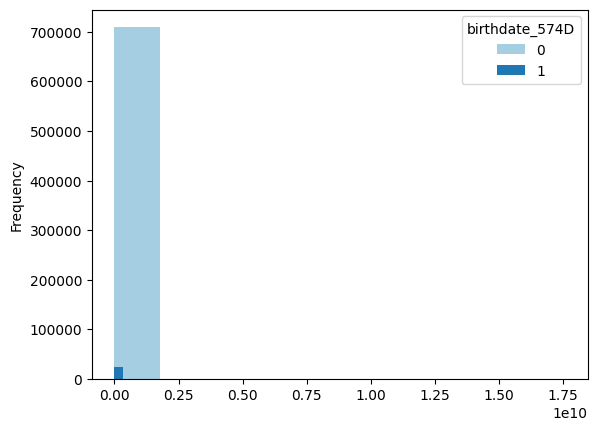

In [ ]:
import matplotlib.pyplot as plt
one = df_train[df_train["target"] == 0].max_collater_valueofguarantee_876L.plot(kind='hist', stacked=True, colormap='Paired', label='0')
zero = df_train[df_train["target"] == 1].max_collater_valueofguarantee_876L.plot(kind='hist', label='1')

plt.legend(title='birthdate_574D')
plt.show()

## Попробуем пойти другим путем и отобрать примеры, на которых модель хуже всего справилась и найти что-то общее. Для этого сделаем predict на train данных и отберем кейсы, где отклонение скора от правильного ответа был больше 0.9(т.е. мы совсем не попали)

In [ ]:
# Пример с unbalance = True


# y_pred_train = pd.Series(model.predict(X_train), index=X_train.index)
# y_pred_train

0          0.343927
1          0.460494
2          0.532601
3          0.695337
4          0.768286
             ...   
1219144    0.446889
1219145    0.207986
1219146    0.724448
1219147    0.725142
1219148    0.107777
Length: 963294, dtype: float64

In [ ]:
y_pred_train = pd.Series(model.predict(X_train), index=X_train.index)
y_pred_train

0          0.017365
1          0.035899
2          0.044325
3          0.066473
4          0.082862
             ...   
1219144    0.030586
1219145    0.021631
1219146    0.067647
1219147    0.092656
1219148    0.009258
Length: 963294, dtype: float64

In [ ]:
diff = y_train - y_pred_train
max_errors_idx = diff[diff>0.9].index
max_errors_idx

Index([      4,     101,     118,     129,     148,     191,     241,     246,
           281,     303,
       ...
       1218435, 1218499, 1218512, 1218588, 1218633, 1218836, 1218921, 1218975,
       1219011, 1219101],
      dtype='int64', length=13736)

In [ ]:
df_train['errors'] = df_train.case_id.apply(lambda x: 1 if x in max_errors_idx else 0)

## Идентифицируем такие кейсы как ошибки и добавим соответствующий столбец

In [ ]:
df_train['errors']

0          0
1          0
2          0
3          0
4          1
          ..
1219144    0
1219145    0
1219146    0
1219147    0
1219148    0
Name: errors, Length: 1219149, dtype: int64

In [ ]:
df_train

,case_id,WEEK_NUM,target,year_decision,month_decision,weekday_decision,assignmentdate_238D,assignmentdate_4527235D,birthdate_574D,dateofbirth_337D,...,max_collaterals_typeofguarante_669M,max_subjectroles_name_541M,max_subjectroles_name_838M,max_collater_valueofguarantee_1124L,max_collater_valueofguarantee_876L,max_pmts_month_158T,max_pmts_month_706T,max_pmts_year_1139T,max_pmts_year_507T,errors
0,0,0,0,2019,1,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1,0,0,2019,1,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2,0,0,2019,1,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,3,0,0,2019,1,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,4,0,1,2019,1,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219144,2670550,59,0,2020,2,1,NaN,NaN,NaN,-13994.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0,0
1219145,2670551,59,0,2020,2,1,NaN,14.0,NaN,-21603.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0,0
1219146,2670552,59,0,2020,2,1,NaN,NaN,NaN,-10921.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0,0
1219147,2670553,59,0,2020,2,1,NaN,NaN,NaN,-19169.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,60000.0,12.0,12.0,2021.0,2020.0,0


In [ ]:
df_train

,case_id,WEEK_NUM,target,year_decision,month_decision,weekday_decision,birthdate_574D,dateofbirth_337D,days120_123L,days180_256L,...,max_collaterals_typeofguarante_669M,max_subjectroles_name_541M,max_subjectroles_name_838M,max_collater_valueofguarantee_1124L,max_collater_valueofguarantee_876L,max_pmts_month_158T,max_pmts_month_706T,max_pmts_year_1139T,max_pmts_year_507T,errors
0,0,0,0,2019,1,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1,0,0,2019,1,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2,0,0,2019,1,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,3,0,0,2019,1,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,4,0,1,2019,1,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219144,2670550,59,0,2020,2,1,NaN,-13994.0,3.0,4.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0,0
1219145,2670551,59,0,2020,2,1,NaN,-21603.0,0.0,3.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0,0
1219146,2670552,59,0,2020,2,1,NaN,-10921.0,4.0,5.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0,0
1219147,2670553,59,0,2020,2,1,NaN,-19169.0,1.0,1.0,...,c7a5ad39,ab3c25cf,ab3c25cf,0.0,60000.0,12.0,12.0,2021.0,2020.0,0


##  Одной из топ фичей был employername_160M, попробуем посмотреть отличаются ли значения для кейсов с ошибками и нет

In [ ]:
df_train[df_train.errors == 1].max_employername_160M.value_counts()

max_employername_160M
5e180ef0        76
d665cd9c        12
f1e4f355        12
P114_118_163    10
a409d8fa        10
                ..
68c7a3bc         0
68c79b9d         0
68c7802e         0
68c75fbe         0
ffffaf43         0
Name: count, Length: 114657, dtype: int64

In [ ]:
df_train[df_train.errors == 0].max_employername_160M.value_counts()

max_employername_160M
5e180ef0       21178
a409d8fa        1986
P157_88_183     1928
d665cd9c        1665
6a3d9351        1613
               ...  
9d163c04           0
289db213           0
22876c3c           0
911957fc           0
f0868189           0
Name: count, Length: 114657, dtype: int64

## Отберем employername, которые встречаются только в кейсах с ошибками(может это какие-то работодатели, которые плохо платят и их работники чаще уходят в дефолт и сформируем из них "черный список"

In [ ]:
strange_employername = set(df_train[df_train.errors == 1].max_employername_160M.unique()) - set(df_train[df_train.errors == 0].max_employername_160M.unique())

In [ ]:
len(strange_employername)

313

## Я попробовал проделать такую же процедуру и на других фичах, но часто отличий от обычных кесов не было

In [ ]:
strange_zipcode = set(df_train[df_train.errors == 1].max_contaddr_zipcode_807M.unique()) - set(df_train[df_train.errors == 0].max_contaddr_zipcode_807M.unique())

In [ ]:
len(strange_zipcode)

0

In [ ]:
strange_name = set(df_train[df_train.errors == 1].max_name_4527232M.unique()) - set(df_train[df_train.errors == 0].max_name_4527232M.unique())

In [ ]:
len(strange_name)

347

In [ ]:
strange_district = set(df_train[df_train.errors == 1].max_district_544M.unique()) - set(df_train[df_train.errors == 0].max_district_544M.unique())

In [ ]:
strange_district

set()

## Далее добавим фичу - встречается ли раотодатель из "черного списка" для данного case_id  и заново обучим модель

In [ ]:
def is_strange_name(row):
    if row.max_employername_160M in strange_employername or row.max_name_4527232M in strange_name:
        return 1
    else:
        return 0



In [ ]:
df_train = df_train.drop(columns=['errors'])
df_train['is_strange_name'] = df_train.apply(is_strange_name, axis=1)

In [ ]:
df_train.is_strange_name = df_train.is_strange_name.astype(bool)

In [ ]:
X = df_train.drop(columns=["target", "case_id", "WEEK_NUM"])
y = df_train["target"]
weeks = df_train["WEEK_NUM"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=False)

models = []
for idx_train, idx_valid in cv.split(X, y, groups=weeks):
    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X.iloc[idx_valid], y.iloc[idx_valid]

    lgb_tr = lgb.Dataset(X_train, y_train, free_raw_data=False)

    params = {
        'objective': 'binary',
        'verbosity': 1,
        'num_threads': 16,
        'eta': 0.1
    }
    lgb_val = lgb.Dataset(X_valid, y_valid, free_raw_data=False)
    params.update({'metric': 'auc'})
    model = lgb.train(params, lgb_tr, num_boost_round=130, valid_sets =[lgb_val], valid_names=['валидация'], callbacks=[lgb.log_evaluation(period=10)])
    models.append(model)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 31565, number of negative: 942582
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.503940 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76527
[LightGBM] [Info] Number of data points in the train set: 974147, number of used features: 431
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032403 -> initscore=-3.396574
[LightGBM] [Info] Start training from score -3.396574
[10]	валидация's auc: 0.791231
[20]	валидация's auc: 0.808166
[30]	валидация's auc: 0.815799
[40]	валидация's auc: 0.820196
[50]	валидация's auc: 0.823601
[60]	валидация's auc: 0.825903
[70]	валидация's auc: 0.827068
[80]	валидация's auc: 0.828233
[90]	валидация's auc: 0

In [ ]:
X_test

,year_decision,month_decision,weekday_decision,assignmentdate_238D,assignmentdate_4527235D,birthdate_574D,dateofbirth_337D,days120_123L,days180_256L,days30_165L,...,max_collaterals_typeofguarante_359M,max_collaterals_typeofguarante_669M,max_subjectroles_name_541M,max_subjectroles_name_838M,max_collater_valueofguarantee_1124L,max_collater_valueofguarantee_876L,max_pmts_month_158T,max_pmts_month_706T,max_pmts_year_1139T,max_pmts_year_507T
case_id,,,,,,,,,,,,,,,,,,,,,
46835,2020,2,2,NaN,NaN,NaN,-10374.0,1.0,1.0,1.0,...,a55475b1,c7a5ad39,a55475b1,ab3c25cf,0.0,NaN,12.0,NaN,2021.0,NaN
47018,2020,2,3,NaN,14.0,NaN,-22155.0,0.0,0.0,0.0,...,a55475b1,c7a5ad39,a55475b1,ab3c25cf,0.0,NaN,12.0,NaN,2021.0,NaN
47186,2020,2,2,NaN,NaN,NaN,-9400.0,5.0,5.0,4.0,...,c7a5ad39,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0
47190,2020,2,2,NaN,NaN,NaN,-10557.0,1.0,1.0,1.0,...,c7a5ad39,a55475b1,ab3c25cf,ab3c25cf,240000.0,0.0,12.0,12.0,2021.0,2020.0
47191,2020,2,2,NaN,NaN,NaN,-10739.0,0.0,0.0,0.0,...,a55475b1,c7a5ad39,a55475b1,ab3c25cf,0.0,NaN,12.0,NaN,2021.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703450,2020,10,1,NaN,NaN,NaN,-22193.0,0.0,0.0,0.0,...,c7a5ad39,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2021.0
2703451,2020,10,1,NaN,NaN,NaN,-25541.0,0.0,0.0,0.0,...,c7a5ad39,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2021.0
2703452,2020,10,1,NaN,NaN,NaN,-15771.0,2.0,2.0,0.0,...,c7a5ad39,c7a5ad39,ab3c25cf,ab3c25cf,0.0,0.0,12.0,12.0,2021.0,2020.0


## Такое дополнение дает небольшой прирост на public скоре (думаю он мог быть больше, но кейсов с работодателями из "черного списка" довольно мало

In [ ]:
X_test['is_strange_name'] = X_test.apply(is_strange_name, axis=1)
X_test['is_strange_name'] = X_test['is_strange_name'].astype('bool')

In [ ]:
y_pred = pd.Series(model.predict(X_test), index=X_test.index)
y_pred.name='score'
y_pred.to_csv('/Users/r/PycharmProjects/ML/data/train/submission.csv')

## Рассмотрим другую базовую модель с фичами, подобранными выше

In [ ]:
weeks = df_train["WEEK_NUM"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=False)

models3 = []
for idx_train, idx_valid in cv.split(X_coded, y, groups=weeks):
    X_train, y_train = X_coded.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X_coded.iloc[idx_valid], y.iloc[idx_valid]

    lgb_tr = lgb.Dataset(X_train, y_train, free_raw_data=False)

    params = {
        "boosting_type": "gbdt",
        "objective": "binary",
        "metric": "auc",
        "max_depth": 10,
        "learning_rate": 0.05,
        "n_estimators": 2000,
        "colsample_bytree": 0.8,
        "colsample_bynode": 0.8,
        "verbose": -1,
        "random_state": 42,
        "reg_alpha": 0.1,
        "reg_lambda": 10,
        "extra_trees":True,
        'num_leaves':64,
        "sample_weight":'balanced',
        "verbose": -1,
    }
    lgb_val = lgb.Dataset(X_valid, y_valid, free_raw_data=False)
    params.update({'metric': 'auc'})
    model = lgb.train(params, lgb_tr, valid_sets =[lgb_val], valid_names=['валидация'], callbacks=[lgb.log_evaluation(200),
                                                                                                   lgb.early_stopping(100)])
    models3.append(model)

/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/lightgbm/engine.py:172: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[200]	валидация's auc: 0.843293
[400]	валидация's auc: 0.849044
[600]	валидация's auc: 0.85076
[800]	валидация's auc: 0.851216
Early stopping, best iteration is:
[882]	валидация's auc: 0.851329


/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/lightgbm/engine.py:172: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[200]	валидация's auc: 0.850044
[400]	валидация's auc: 0.855423
[600]	валидация's auc: 0.856815
[800]	валидация's auc: 0.857386
[1000]	валидация's auc: 0.857854
Early stopping, best iteration is:
[1022]	валидация's auc: 0.857867


/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/lightgbm/engine.py:172: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[200]	валидация's auc: 0.843183
[400]	валидация's auc: 0.848851
[600]	валидация's auc: 0.85057
[800]	валидация's auc: 0.851291
[1000]	валидация's auc: 0.851565
Early stopping, best iteration is:
[905]	валидация's auc: 0.851652


/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/lightgbm/engine.py:172: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[200]	валидация's auc: 0.849446
[400]	валидация's auc: 0.854732
[600]	валидация's auc: 0.856263
[800]	валидация's auc: 0.856819
[1000]	валидация's auc: 0.857125
[1200]	валидация's auc: 0.857162
Early stopping, best iteration is:
[1162]	валидация's auc: 0.857255


/Users/ruaaapb/PycharmProjects/ML/.venv/lib/python3.10/site-packages/lightgbm/engine.py:172: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[200]	валидация's auc: 0.845282
[400]	валидация's auc: 0.850855
[600]	валидация's auc: 0.852612
[800]	валидация's auc: 0.853297
[1000]	валидация's auc: 0.853381
Early stopping, best iteration is:
[950]	валидация's auc: 0.853463


In [ ]:
model = FinalModel(models3)

In [ ]:
y_pred = pd.Series(model.predict(X_test_coded), index=X_test_coded.index)
y_pred

case_id
46835      0.170923
47018      0.010050
47186      0.070568
47190      0.065652
47191      0.030471
             ...   
2703450    0.001415
2703451    0.006955
2703452    0.150411
2703453    0.003142
2703454    0.005969
Length: 307510, dtype: float64

In [ ]:
y_pred.name='score'
y_pred.to_csv('/Users/r/PycharmProjects/ML/data/train/submission.csv')